<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 126 · MLOps Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Operationalizing the Model</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">A churn model through 18 months of production life: package and serve it, log every prediction, monitor for decay, detect drift with PSI before the labels arrive, diagnose concept drift, retrain a challenger, validate it, and roll it out safely, the full MLOps loop.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Operationalizing the Model: an MLOps Case Study
The earlier case studies ended when the model was good. In the real world that is the halfway point. A model in production is a living system: it must be **packaged**, **served**, and above all **watched**, because the world it learned from keeps changing. This project takes a churn model through 18 months of production life. It starts healthy, silently decays as the market shifts, sets off a drift alarm, gets diagnosed, retrained, validated, and safely rolled back out, the full **MLOps** loop.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import joblib, os, time
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, precision_score
import warnings; warnings.filterwarnings('ignore')

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">REAL DATA &#183; THE PRODUCTION LOG</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">18 months of a deployed churn model</div>
<div style="color:#4a5578;margin-top:6px">month 0 is the training window; months 1-18 are live scored customers with outcomes.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/model_monitoring.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'model_monitoring.csv')
df = df.drop_duplicates('customer_id').reset_index(drop=True)
FEATS = ['tenure_months','monthly_usage_gb','support_tickets','add_ons','monthly_charges','price_increase']
print('rows:', len(df), '| months:', sorted(df.month.unique()))
df.head(3)

rows: 14800 | months: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]


,customer_id,month,tenure_months,monthly_usage_gb,support_tickets,add_ons,monthly_charges,price_increase,churned
0,C100000,0,31,75.6,4,0,67.57,0,0
1,C100001,0,32,49.1,2,0,57.96,0,0
2,C100002,0,72,71.6,4,3,82.85,0,1


Each row is one customer scored in a given `month`, with the features the model saw and the `churned` outcome that arrived later. **Month 0** is the reference window the model was trained on; **months 1 to 18** are the live production stream.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 1 &#183; DEFINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What does 'healthy in production' mean?</div>
<div style="color:#4a5578;margin-top:6px">A model needs a service-level contract, not just an accuracy number.</div>
</div>

Before deploying anything, write down what must stay true in production. This is the contract monitoring will check against.

In [4]:
CONTRACT = {
  'performance_floor_auc': 0.65,     # retrain trigger if rolling AUC drops below this
  'drift_alert_psi': 0.25,           # investigate any feature whose PSI exceeds this
  'max_latency_ms': 50,              # scoring must be fast enough for the app
  'label_delay_months': 2,           # churn is only confirmed about 2 months later
}
for k,v in CONTRACT.items(): print(f'{k:24s} {v}')
print('\nKey tension: PERFORMANCE needs labels (they arrive late), so we also watch INPUT drift, which needs no labels.')

performance_floor_auc    0.65
drift_alert_psi          0.25
max_latency_ms           50
label_delay_months       2

Key tension: PERFORMANCE needs labels (they arrive late), so we also watch INPUT drift, which needs no labels.


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 2 &#183; PACKAGE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Train the champion, then freeze it</div>
<div style="color:#4a5578;margin-top:6px">A deployable artifact is the pipeline plus its metadata.</div>
</div>

In [5]:
ref = df[df.month == 0]
champion = Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler()),
                     ('clf',LogisticRegression(max_iter=2000, class_weight='balanced'))]).fit(ref[FEATS], ref.churned)
meta = {'model_version':'v1.0','trained_on_month':0, 'n_train':len(ref), 'features':FEATS,
        'train_auc': round(roc_auc_score(ref.churned, champion.predict_proba(ref[FEATS])[:,1]), 3)}
joblib.dump({'model':champion,'meta':meta}, 'churn_model.joblib')
print('packaged churn_model.joblib'); print(meta)

packaged churn_model.joblib
{'model_version': 'v1.0', 'trained_on_month': 0, 'n_train': 4000, 'features': ['tenure_months', 'monthly_usage_gb', 'support_tickets', 'add_ons', 'monthly_charges', 'price_increase'], 'train_auc': 0.772}


The artifact bundles the **whole pipeline** (imputer, scaler, model) so the exact preprocessing travels with the weights, plus **metadata** (version, training window, feature list). Versioning is what makes a later rollback possible.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 3 &#183; SERVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Load the artifact and score customers</div>
<div style="color:#4a5578;margin-top:6px">A scoring service is just load-once, predict-many, behind a decision rule.</div>
</div>

In [6]:
bundle = joblib.load('churn_model.joblib'); model = bundle['model']
def score(rows, threshold=0.5):
    p = model.predict_proba(rows[FEATS])[:,1]
    return pd.DataFrame({'customer_id':rows.customer_id.values, 'risk':p.round(3),
                         'action':np.where(p>=threshold,'RETAIN OUTREACH','none')})
batch = df[df.month==1].head(5)
t0=time.perf_counter(); out=score(batch); ms=(time.perf_counter()-t0)*1000
print(f'scored {len(batch)} customers in {ms:.1f} ms  (contract allows {CONTRACT["max_latency_ms"]} ms)')
out

scored 5 customers in 0.9 ms  (contract allows 50 ms)


,customer_id,risk,action
0,C104000,0.522,RETAIN OUTREACH
1,C104001,0.168,none
2,C104002,0.261,none
3,C104003,0.645,RETAIN OUTREACH
4,C104004,0.633,RETAIN OUTREACH


In production this function sits behind an API or a batch job. It **loads the artifact once** and scores many rows, turning each probability into an action at the chosen threshold. We also time it, latency is part of the contract.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 4 &#183; LOG</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Record every prediction</div>
<div style="color:#4a5578;margin-top:6px">You cannot monitor what you did not log.</div>
</div>

In [7]:
log = df[df.month>=1][['customer_id','month']+FEATS].copy()
log['risk'] = model.predict_proba(log[FEATS])[:,1]
log['churned'] = df[df.month>=1]['churned'].values     # the label, joined in later as it arrives
print('prediction log rows:', len(log)); log.groupby('month').agg(n=('risk','size'), mean_risk=('risk','mean')).head()

prediction log rows: 10800


,n,mean_risk
month,,
1,600,0.438078
2,600,0.447270
3,600,0.429149
4,600,0.428680
5,600,0.434479


Every score is written to a **prediction log** with its inputs, the model output, and (once known) the outcome. This log is the raw material for every monitoring check that follows.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 5 &#183; MONITOR</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Watch performance decay in slow motion</div>
<div style="color:#4a5578;margin-top:6px">Rolling metrics turn a silent problem into a visible one.</div>
</div>

In [8]:
monthly = log.groupby('month').apply(lambda g: pd.Series({
    'n':len(g), 'mean_risk':g.risk.mean(), 'churn_rate':g.churned.mean(),
    'auc': roc_auc_score(g.churned, g.risk) if g.churned.nunique()>1 else np.nan})).reset_index()
print(monthly[['month','churn_rate','mean_risk','auc']].round(3).to_string(index=False))

 month  churn_rate  mean_risk   auc
     1       0.202      0.438 0.770
     2       0.225      0.447 0.726
     3       0.212      0.429 0.770
     4       0.227      0.429 0.773
     5       0.205      0.434 0.772
     6       0.232      0.448 0.711
     7       0.287      0.524 0.631
     8       0.357      0.627 0.609
     9       0.422      0.707 0.533
    10       0.422      0.706 0.556
    11       0.403      0.703 0.548
    12       0.448      0.708 0.548
    13       0.418      0.695 0.499
    14       0.417      0.704 0.509
    15       0.437      0.702 0.515
    16       0.445      0.690 0.554
    17       0.467      0.711 0.549
    18       0.402      0.695 0.541


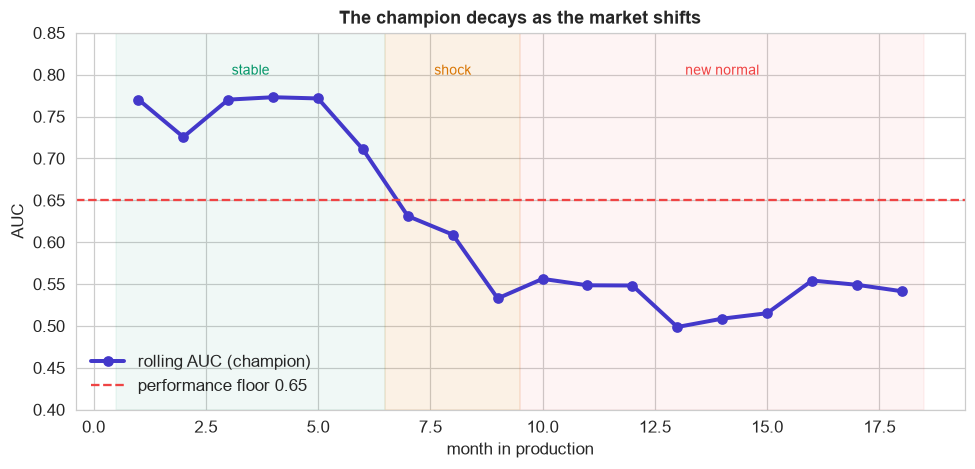

stable AUC (m1-6): 0.754  ->  new-normal AUC (m13-18): 0.528


In [9]:
fig,ax=plt.subplots(figsize=(9,4.4))
ax.plot(monthly.month, monthly.auc, 'o-', color=EM, lw=2.6, label='rolling AUC (champion)')
ax.axhline(CONTRACT['performance_floor_auc'], color=RED, ls='--', label='performance floor 0.65')
ax.axvspan(0.5,6.5,color=GREEN,alpha=0.06); ax.axvspan(6.5,9.5,color=AMBER,alpha=0.10); ax.axvspan(9.5,18.5,color=RED,alpha=0.06)
ax.text(3.5,0.80,'stable',color=GREEN,ha='center',fontsize=9); ax.text(8,0.80,'shock',color=AMBER,ha='center',fontsize=9); ax.text(14,0.80,'new normal',color=RED,ha='center',fontsize=9)
ax.set(xlabel='month in production', ylabel='AUC', title='The champion decays as the market shifts', ylim=(0.4,0.85)); ax.legend(loc='lower left'); plt.tight_layout(); plt.show()
print('stable AUC (m1-6): %.3f  ->  new-normal AUC (m13-18): %.3f' % (monthly[monthly.month.between(1,6)].auc.mean(), monthly[monthly.month.between(13,18)].auc.mean()))

The champion holds around **0.77** for six months, then slides through the shock to about **0.53**, no better than a coin flip, and it stays there. Nothing errored; the model just quietly stopped working as the world changed. Rolling metrics are what make that visible.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 6 &#183; DETECT DRIFT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Measure how far the inputs have moved</div>
<div style="color:#4a5578;margin-top:6px">PSI flags a shifted feature without needing a single label.</div>
</div>

In [10]:
def psi(ref_vals, cur_vals, bins=10):
    ref_vals = pd.Series(ref_vals).dropna(); cur_vals = pd.Series(cur_vals).dropna()
    edges = np.quantile(ref_vals, np.linspace(0,1,bins+1)); edges[0]=-np.inf; edges[-1]=np.inf
    r = np.clip(np.histogram(ref_vals, edges)[0]/len(ref_vals), 1e-4, None)
    c = np.clip(np.histogram(cur_vals, edges)[0]/len(cur_vals), 1e-4, None)
    return float(np.sum((c-r)*np.log(c/r)))
recent = df[df.month.between(13,18)]
psi_now = {f: round(psi(ref[f], recent[f]),3) for f in FEATS}
print('PSI (reference month 0  vs  recent months 13-18):')
for f,v in sorted(psi_now.items(), key=lambda x:-x[1]): flag='  <-- DRIFT' if v>CONTRACT['drift_alert_psi'] else ''; print(f'  {f:20s} {v:6.3f}{flag}')

PSI (reference month 0  vs  recent months 13-18):
  support_tickets       1.598  <-- DRIFT
  price_increase        1.047  <-- DRIFT
  monthly_charges       0.179
  monthly_usage_gb      0.163
  tenure_months         0.006
  add_ons               0.001


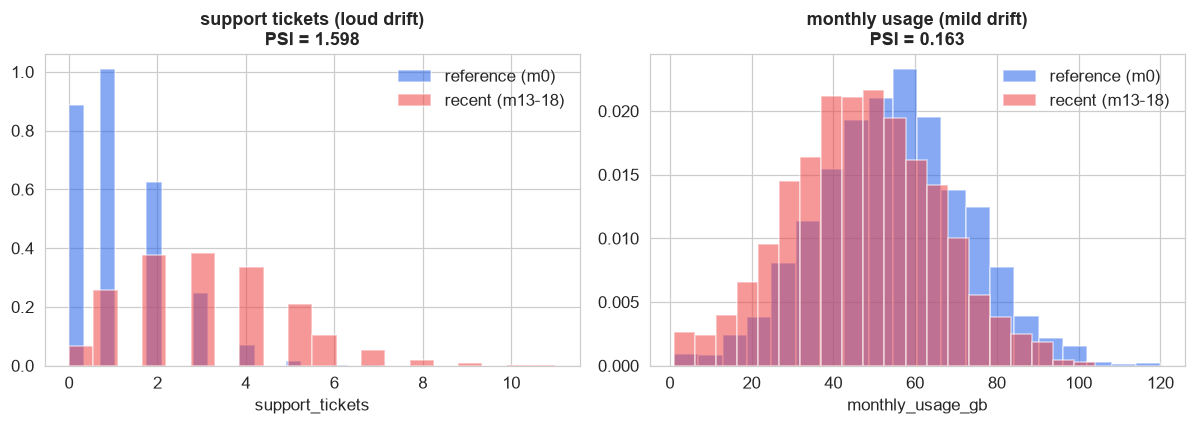

rule of thumb: PSI < 0.1 stable | 0.1-0.25 watch | > 0.25 significant drift


In [11]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
for a,(f,ttl) in zip(ax, [('support_tickets','support tickets (loud drift)'),('monthly_usage_gb','monthly usage (mild drift)')]):
    a.hist(ref[f].dropna(), bins=20, density=True, alpha=0.55, color=BLUE, label='reference (m0)')
    a.hist(recent[f].dropna(), bins=20, density=True, alpha=0.55, color=RED, label='recent (m13-18)')
    a.set(title=f'{ttl}\nPSI = {psi_now[f]}', xlabel=f); a.legend()
plt.tight_layout(); plt.show()
print('rule of thumb: PSI < 0.1 stable | 0.1-0.25 watch | > 0.25 significant drift')

**Population Stability Index** compares each feature's current distribution against the training reference. `support_tickets` has moved enormously (PSI far above 0.25), `monthly_usage` only mildly. Crucially, PSI needs **no outcomes**, so it can fire while we are still waiting for churn labels to confirm.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 7 &#183; ALERT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Input drift leads, performance lags</div>
<div style="color:#4a5578;margin-top:6px">Watch the leading indicator, because labels arrive late.</div>
</div>

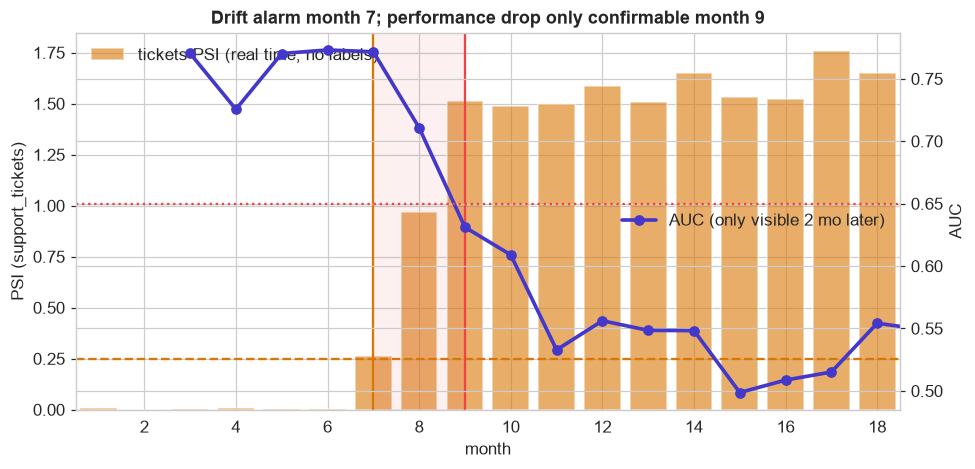

PSI alarm: month 7 (real time). Performance drop happened month 7 but is only confirmable month 9 once labels arrive.
-> input drift buys a 2-month head start (shaded).


In [12]:
delay = CONTRACT['label_delay_months']    # churn labels only arrive 2 months after scoring
psi_by_month = pd.DataFrame({'month':range(1,19),
    'tickets_psi':[psi(ref.support_tickets, df[df.month==m].support_tickets) for m in range(1,19)]})
psi_by_month = psi_by_month.merge(monthly[['month','auc']], on='month')
psi_fire = int(psi_by_month[psi_by_month.tickets_psi>0.25].month.min())          # observable in real time
auc_true = int(psi_by_month[psi_by_month.auc<0.65].month.min())                   # month performance truly dropped
auc_known = auc_true + delay                                                       # month we could CONFIRM it (labels lag)
fig,ax=plt.subplots(figsize=(9,4.4)); ax2=ax.twinx()
ax.bar(psi_by_month.month, psi_by_month.tickets_psi, color=AMBER, alpha=0.60, label='tickets PSI (real time, no labels)')
ax.axhline(CONTRACT['drift_alert_psi'], color=AMBER, ls='--')
# AUC is only OBSERVABLE 'delay' months after the fact -> plot it shifted to when you would actually see it
ax2.plot(psi_by_month.month+delay, psi_by_month.auc, 'o-', color=EM, lw=2.4, label=f'AUC (only visible {delay} mo later)')
ax2.axhline(CONTRACT['performance_floor_auc'], color=RED, ls=':')
ax.axvspan(psi_fire, auc_known, color=RED, alpha=0.08)
ax.axvline(psi_fire,color=AMBER,lw=1.5); ax.axvline(auc_known,color=RED,lw=1.5)
ax.set(xlabel='month', ylabel='PSI (support_tickets)', title=f'Drift alarm month {psi_fire}; performance drop only confirmable month {auc_known}', xlim=(0.5,18.5)); ax2.set_ylabel('AUC')
ax.legend(loc='upper left'); ax2.legend(loc='center right'); plt.tight_layout(); plt.show()
print(f'PSI alarm: month {psi_fire} (real time). Performance drop happened month {auc_true} but is only confirmable month {auc_known} once labels arrive.')
print(f'-> input drift buys a {auc_known-psi_fire}-month head start (shaded).')

This is the central MLOps lesson. The **PSI alarm fires at month 7**, the instant support tickets shift, using **no labels at all**. Performance actually dropped that same month, but churn outcomes lag by two months, so the AUC breach is not **confirmable until month 9**. The shaded gap is time you would have flown blind if you only watched performance. In production you act on the **leading** signal, because waiting for the **lagging** one costs months of bad decisions.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 8 &#183; DIAGNOSE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Data drift or concept drift?</div>
<div style="color:#4a5578;margin-top:6px">The fix depends on which one you have.</div>
</div>

In [13]:
# fit a fresh logistic on reference vs recent and compare the standardized coefficient on usage
def usage_coef(data):
    p = Pipeline([('s',StandardScaler()),('c',LogisticRegression(max_iter=1000))]).fit(data[FEATS].fillna(data[FEATS].median()), data.churned)
    return p.named_steps['c'].coef_[0][FEATS.index('monthly_usage_gb')]
print('monthly_usage -> churn coefficient')
print('  reference (m0)     : %+.3f   (LOW usage predicted churn)' % usage_coef(ref))
print('  recent    (m13-18): %+.3f   (now HIGH usage predicts churn)' % usage_coef(recent))
print('\nThe sign FLIPPED: the relationship itself changed. That is CONCEPT drift, and no amount of rescaling fixes it -- only retraining does.')

monthly_usage -> churn coefficient
  reference (m0)     : -1.048   (LOW usage predicted churn)
  recent    (m13-18): +0.433   (now HIGH usage predicts churn)

The sign FLIPPED: the relationship itself changed. That is CONCEPT drift, and no amount of rescaling fixes it -- only retraining does.


Two questions: did the **inputs** move (data drift, fix by recalibrating or gathering the new range) or did the **relationship** move (concept drift, fix by retraining)? Fitting a fresh model on recent data shows the `monthly_usage` coefficient has **flipped sign**: once, disengaged low-usage customers churned; now high-usage customers hit the price increase and leave. The champion's learned rule is backwards, so retraining is the only cure.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 9 &#183; RETRAIN</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit a challenger on fresh data</div>
<div style="color:#4a5578;margin-top:6px">Retrain on the new steady state, not the whole muddled history.</div>
</div>

In [14]:
train_win = df[df.month.between(10,12)]     # the new steady state, after the shock settled
challenger = Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler()),
                       ('clf',LogisticRegression(max_iter=2000, class_weight='balanced'))]).fit(train_win[FEATS], train_win.churned)
print('challenger trained on months 10-12, n =', len(train_win))

challenger trained on months 10-12, n = 1800


The challenger is trained on the **most recent stable window** (months 10 to 12), after the shock settled into a new normal. Training on the whole 18-month history would blend two contradictory regimes and learn a muddle.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 10 &#183; VALIDATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Never promote a challenger on faith</div>
<div style="color:#4a5578;margin-top:6px">Compare champion and challenger on held-out fresh data.</div>
</div>

on held-out months 13-18:
  aged champion   AUC 0.529  recall 0.83
  new challenger  AUC 0.737  recall 0.68
  lift: +0.208 AUC


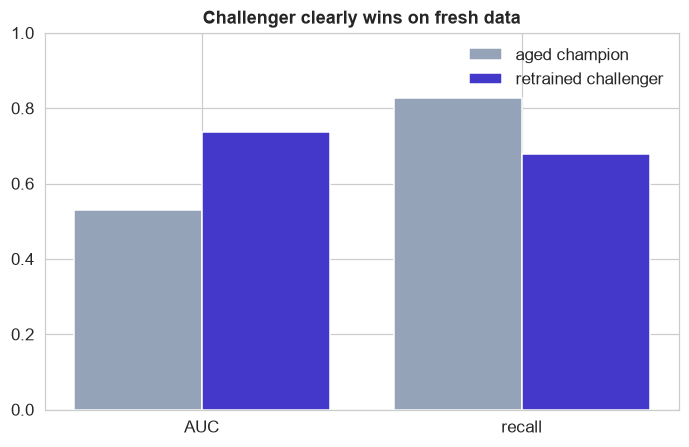

In [15]:
holdout = df[df.month.between(13,18)]
def evalm(m): p=m.predict_proba(holdout[FEATS])[:,1]; return roc_auc_score(holdout.churned,p), recall_score(holdout.churned,(p>=0.5).astype(int))
c_auc,c_rec = evalm(champion); h_auc,h_rec = evalm(challenger)
print('on held-out months 13-18:')
print(f'  aged champion   AUC {c_auc:.3f}  recall {c_rec:.2f}')
print(f'  new challenger  AUC {h_auc:.3f}  recall {h_rec:.2f}')
print(f'  lift: +{h_auc-c_auc:.3f} AUC')
fig,ax=plt.subplots(figsize=(6.4,4.2)); x=np.arange(2)
ax.bar(x-0.2,[c_auc,c_rec],0.4,label='aged champion',color=GREY); ax.bar(x+0.2,[h_auc,h_rec],0.4,label='retrained challenger',color=EM)
ax.set_xticks(x); ax.set_xticklabels(['AUC','recall']); ax.set(title='Challenger clearly wins on fresh data',ylim=(0,1)); ax.legend(); plt.tight_layout(); plt.show()

On data neither model trained on, the challenger beats the aged champion decisively (AUC about **0.74 vs 0.53**). Only a win this clear, on **held-out recent data**, justifies promotion.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 11 &#183; ROLL OUT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Promote safely, not all at once</div>
<div style="color:#4a5578;margin-top:6px">Shadow, then canary, with a rollback rule armed.</div>
</div>

In [16]:
# CANARY: route a slice of live traffic to the challenger, keep the rest on champion, compare
canary = df[df.month==14].copy(); rng=np.random.default_rng(0)
canary['arm'] = np.where(rng.random(len(canary))<0.20, 'challenger', 'champion')   # 20% canary
for arm,m in [('champion',champion),('challenger',challenger)]:
    grp=canary[canary.arm==arm]; a=roc_auc_score(grp.churned, m.predict_proba(grp[FEATS])[:,1])
    print(f'  {arm:11s} arm: n={len(grp):3d}  AUC={a:.3f}')
print('\nrollback rule: if the canary AUC drops below the champion by more than 0.02, auto-revert to v1.0.')
print('here the challenger arm is far better, so we widen the canary 20% -> 50% -> 100%.')

  champion    arm: n=485  AUC=0.498
  challenger  arm: n=115  AUC=0.789

rollback rule: if the canary AUC drops below the champion by more than 0.02, auto-revert to v1.0.
here the challenger arm is far better, so we widen the canary 20% -> 50% -> 100%.


A safe rollout is gradual. **Shadow** mode scores live traffic without acting on it; a **canary** sends a small slice (here 20%) to the challenger and compares. A **rollback rule** stays armed the whole time, if the new model underperforms, traffic reverts to the versioned champion automatically. Only after the canary holds do we widen to 100%.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">STEP 12 &#183; GOVERN &amp; REDEPLOY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Promote the challenger and close the loop</div>
<div style="color:#4a5578;margin-top:6px">The promoted model becomes the new champion, and monitoring starts again.</div>
</div>

In [17]:
# promote: the challenger becomes v2.0 and is packaged exactly like v1.0 was
meta2 = {'model_version':'v2.0','trained_on_month':'10-12','features':FEATS,'supersedes':'v1.0'}
joblib.dump({'model':challenger,'meta':meta2}, 'churn_model.joblib')
print('promoted -> churn_model.joblib is now', meta2['model_version'])
# score a brand-new batch of customers with the PROMOTED model
prod = joblib.load('churn_model.joblib'); m2 = prod['model']
new_customers = pd.DataFrame({'tenure_months':[8,40],'monthly_usage_gb':[95,20],'support_tickets':[6,0],
                              'add_ons':[0,3],'monthly_charges':[120,60],'price_increase':[1,0]})
new_customers['risk'] = m2.predict_proba(new_customers[FEATS])[:,1].round(3)
new_customers['action'] = np.where(new_customers.risk>=0.5,'RETAIN OUTREACH','monitor')
print(new_customers[['tenure_months','monthly_usage_gb','support_tickets','price_increase','risk','action']].to_string(index=False))

promoted -> churn_model.joblib is now v2.0
 tenure_months  monthly_usage_gb  support_tickets  price_increase  risk          action
             8                95                6               1 0.975 RETAIN OUTREACH
            40                20                0               0 0.045         monitor


The promoted challenger (**v2.0**) is packaged and served exactly as v1.0 was, and here it scores two brand-new customers: the high-usage subscriber on a price increase is flagged, the settled low-usage one is not, correctly, under the **new** relationship the aged champion got backwards. Then monitoring resumes: the loop never ends. That is the difference between a model and a **product**.

## The MLOps loop, in one view

1. **Define** the production contract: performance floor, drift threshold, latency, label delay.
2. **Package** the pipeline plus metadata into a versioned artifact.
3. **Serve** it behind a fast load-once, predict-many function.
4. **Log** every prediction with its inputs and (later) its outcome.
5. **Monitor** rolling performance, score distribution, and outcome rate.
6. **Detect drift** with PSI on inputs, which needs no labels.
7. **Alert** on the leading signal, because labels lag by months.
8. **Diagnose** data drift versus concept drift; the sign flip means concept drift.
9. **Retrain** a challenger on the recent steady state.
10. **Validate** the challenger against the champion on held-out fresh data.
11. **Roll out** with shadow then canary, a rollback rule always armed.
12. **Govern** and redeploy: the challenger becomes the champion, and monitoring restarts.

**The one idea to keep: a deployed model is not finished, it is on the clock. The world drifts, so the real deliverable is the closed loop that watches for decay and renews the model, not the model itself.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>